<a href="https://colab.research.google.com/github/Toomito/trabajo-final-icd-2026/blob/main/TrabajoFinal_ICD_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final - Introducción a Ciencia de Datos 2026
**Alumnos:** crypto, fistita, tanque
**Dataset:** Default of Credit Card Clients (UCI / Kaggle)
**Objetivo:** Predecir incumplimiento de pago de tarjetas de crédito

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tomasplaya","key":"96d72fd7db40bfccb8d70ed95454bebd"}'}

In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset
!unzip default-of-credit-card-clients-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
100% 0.98M/0.98M [00:00<00:00, 125MB/s]

Archive:  default-of-credit-card-clients-dataset.zip
  inflating: UCI_Credit_Card.csv     


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('UCI_Credit_Card.csv')

print("Forma del dataset:", df.shape)
df.head()

Forma del dataset: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


##Exploracion inicial del dataset

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

#####Al realizar df.info() vemos que nuestro csv no cuenta con datos nullos y ademas vemos que cuenta con integer y floats (eteros y no enteros)                                                 Observamos que el nombre de default.payment.next.month es un poco incomodo para trabajar por el mismo asi que lo renombraremos a

In [32]:
df.rename(columns={'default.payment.next.month': 'PAYMENTNM'},inplace=True) #renombre de la columna
print("Columnas actualziadas con exito")
print(df.columns.tolist()) #imprime la lista de columasn

Columnas actualziadas con exito
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAYMENTNM']


###### La columna renombrada como PAYMENTNM nos otogra dice

0 si el cliente paga su tarjeta

1 si el cliente NO paga su tarjeta (incumplimeinto de pago)

La idea central es que nuestro modelo aprendera desde nuestro CSV para predecir el valor de PAYMENTNM

Para esto, analizaremos la distribucion de nuestra columan PAYMENTNM, viendo cuantos usuarios paga o no pagan sus tarjetas actualmente

In [33]:
print("Distribucion")
print(df['PAYMENTNM'].value_counts())
print("\nCalculo de procentaje:")
print(df['PAYMENTNM'].value_counts(normalize=True)* 100)

Distribucion
PAYMENTNM
0    23364
1     6636
Name: count, dtype: int64

Calculo de procentaje:
PAYMENTNM
0    77.88
1    22.12
Name: proportion, dtype: float64


###### Vemos que nuestro dataset no esta balanceado y eso afectara a el entremiento de nuestro modelo

Para ver esto de una mejor forma, presentamos el siguiente grafico


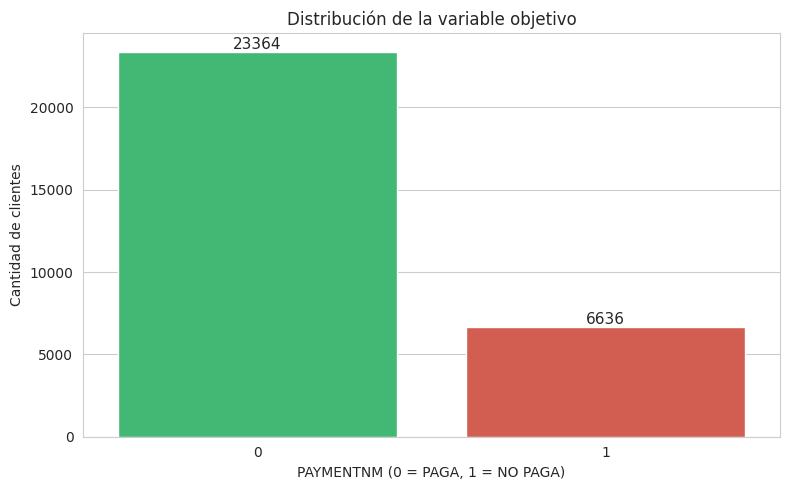

In [45]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='PAYMENTNM', data=df, hue='PAYMENTNM',
                   palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribución de la variable objetivo')
plt.xlabel('PAYMENTNM (0 = PAGA, 1 = NO PAGA)')
plt.ylabel('Cantidad de clientes')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

### Observaciones sobre la distribución

El gráfico revela que el dataset está **fuertemente desbalanceado**:

- **23.364 clientes (77.88%)** cumplen con el pago de su tarjeta de crédito.
- **6.636 clientes (22.12%)** incumplen el pago del próximo mes.

Esto significa que por cada cliente que incumple, hay aproximadamente **3,5 clientes
que pagan**. El desbalance tiene dos consecuencias importantes para el análisis:

Como siguiente paso, procederemos a realizar una exploracion de las varibales mas importantes que suaremos para entendear a nuestro modelo

Realizaremos una exploracion en las variables SEX,EDUCATION,MARRIGE,AGE para ver que no tengamos informacion erronea o datos mal carados en nuestro CSV que luego nos pueden llevar a un mal entrenamiento del modelo


In [51]:
# Revision de valores

#VARIABLE CATEGORICA
print("SEX - valores únicos:", sorted(df['SEX'].unique()))
print("SEX - cantidad por valor:")
print(df['SEX'].value_counts().sort_index())
print()

#VARIABLE CATEGORICA
print("EDUCATION - valores únicos:", sorted(df['EDUCATION'].unique()))
print("EDUCATION - cantidad por valor:")
print(df['EDUCATION'].value_counts().sort_index())
print()

#VARIABLE CATEGORICA
print("MARRIAGE - valores únicos:", sorted(df['MARRIAGE'].unique()))
print("MARRIAGE - cantidad por valor:")
print(df['MARRIAGE'].value_counts().sort_index())
print()

#VARIABLE NUMERICA
print("AGE - estadísticas:")
print(f"  Mínimo:   {df['AGE'].min()} años")
print(f"  Máximo:   {df['AGE'].max()} años")
print(f"  Media:    {df['AGE'].mean():.2f} años")
print(f"  Mediana:  {df['AGE'].median()} años")
print(f"  Desvío:   {df['AGE'].std():.2f}")
print(f"  Cantidad de valores únicos: {df['AGE'].nunique()}")

SEX - valores únicos: [np.int64(1), np.int64(2)]
SEX - cantidad por valor:
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION - valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
EDUCATION - cantidad por valor:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE - valores únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
MARRIAGE - cantidad por valor:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

AGE - estadísticas:
  Mínimo:   21 años
  Máximo:   79 años
  Media:    35.49 años
  Mediana:  34.0 años
  Desvío:   9.22
  Cantidad de valores únicos: 56


### Resumen del análisis de variables demográficas

A partir del análisis de las variables más importantes, podemos resumir lo siguiente:

#### 1. SEX (sexo)

Toma valores **1 y 2**:

- `1` = Hombre
- `2` = Mujer

Esta variable está limpia, no presenta valores inesperados.

#### 2. EDUCATION (nivel educativo)

Toma valores **del 0 al 6**:

- `1` = Graduado universitario
- `2` = Universidad
- `3` = Secundario
- `4` = Otros
- `0`, `5`, `6` = **No están documentados** ← problema a tratar en la limpieza

#### 3. MARRIAGE (estado civil)

Toma valores **del 0 al 3**:

- `1` = Casado
- `2` = Soltero
- `3` = Otros
- `0` = **No está documentado** ← problema a tratar en la limpieza

#### 4. AGE (edad)

Variable numérica continua:

- **Mínimo:** 21 años
- **Máximo:** 79 años

---





Como siguiente paso, la idea es "Limpiar" aquellos valores no documentados que nos podrian llevar a problemas en el entrenamiento del modelo